# Big Data Lab 2 — Query Performance: DuckDB over CSV vs Parquet

In this lab, you’ll learn to reason and care about performance when querying data files. We take one canonical slice of taxi trips and store it three ways (CSV, Parquet, partitioned Parquet), then run the same SQL queries with **DuckDB** — an in-process analytics database that can query files directly (no server). We won't stop at reporting timings, but rather we'll explain them using evidence from `EXPLAIN`.

## What you’ll do (end-to-end)
- Build the *same* dataset in three storage layouts:
  - CSV (row-oriented, text)
  - Parquet (single file, columnar)
  - Partitioned Parquet (columnar + partition pruning)
- Run a query suite and **measure** runtime.
- Use `EXPLAIN` / `EXPLAIN ANALYZE` to connect performance results to execution plans.

## Why this matters
In real data engineering, you often query files directly (data lake / object storage).
Format + layout choices can change runtime, cost, and operational reliability.

## Evaluation
50% correctness/completion + 50% explanation.
Be ready to explain: parsing overhead, columnar storage, predicate pushdown, column pruning, partition pruning, and small-file tradeoffs.


## Setup (run once)
This lab uses DuckDB + PyArrow and produces files in a local folder (or Google Drive).


In [1]:
!pip -q install duckdb pyarrow matplotlib

from pathlib import Path
import time
import shutil

import duckdb
import pandas as pd
import pyarrow as pa
import pyarrow.csv as pacsv
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

print("duckdb", duckdb.__version__)
print("pyarrow", pa.__version__)


duckdb 1.3.2
pyarrow 18.1.0


## Optional: Persist outputs in Google Drive
If you want files to survive Colab restarts, mount Drive.


In [2]:
USE_DRIVE = False  # <- change to True to persist outputs in Google Drive

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/BDLab/Lab2")
else:
    BASE_DIR = Path("/content/BDLab/Lab2")

RAW_DIR = BASE_DIR / "raw"
OUT_DIR = BASE_DIR / "out"
RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_DIR


PosixPath('/content/BDLab/Lab2')

## 1) Download a real dataset (NYC Taxi trip data)
We’ll use a single month of Yellow Taxi trips, then slice the first days to keep runtime reasonable.

If this is slow on a busy day, reduce `END_DAY_EXCL`.


In [3]:
YEAR = 2024
MONTH = 1

START_DAY = 1
END_DAY_EXCL = 8  # exclusive (1..7)

url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{YEAR}-{MONTH:02d}.parquet"
raw_path = RAW_DIR / f"yellow_tripdata_{YEAR}-{MONTH:02d}.parquet"

if not raw_path.exists():
    print("Downloading:", url)
    !wget -q "{url}" -O "{raw_path}"
else:
    print("Already downloaded:", raw_path)

raw_path, raw_path.stat().st_size / (1024*1024)


Downloading: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet


(PosixPath('/content/BDLab/Lab2/raw/yellow_tripdata_2024-01.parquet'),
 47.64713382720947)

## 2) Inspect schema & preview rows
We’ll use DuckDB to inspect the Parquet without loading everything into memory.


In [4]:
con = duckdb.connect()

schema_df = con.execute(
    f"DESCRIBE SELECT * FROM read_parquet('{raw_path.as_posix()}')"
).df()

schema_df


,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,BIGINT,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,BIGINT,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,INTEGER,YES,None,None,None
8,DOLocationID,INTEGER,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


In [5]:
sample_df = con.execute(
    f"SELECT * FROM read_parquet('{raw_path.as_posix()}') LIMIT 5"
).df()

sample_df


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.80,1,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.70,1,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.40,1,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.80,1,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


## 3) Build one *canonical* dataset
Key idea: we want the *same logical data* stored in multiple physical layouts.

We add a derived column `pickup_date` which we’ll use for partitioning and date filters.


In [6]:
start_date = f"{YEAR}-{MONTH:02d}-{START_DAY:02d}"
end_date = f"{YEAR}-{MONTH:02d}-{END_DAY_EXCL:02d}"  # exclusive

parquet_ref = f"read_parquet('{raw_path.as_posix()}')"

canonical_sql = f"""
SELECT
  tpep_pickup_datetime,
  tpep_dropoff_datetime,
  PULocationID,
  DOLocationID,
  passenger_count,
  trip_distance,
  fare_amount,
  tip_amount,
  total_amount,
  CAST(tpep_pickup_datetime AS DATE) AS pickup_date
FROM {parquet_ref}
WHERE
  tpep_pickup_datetime >= TIMESTAMP '{start_date}'
  AND tpep_pickup_datetime <  TIMESTAMP '{end_date}'
  AND tpep_dropoff_datetime >= tpep_pickup_datetime
  AND trip_distance >= 0
  AND fare_amount >= 0
  AND total_amount >= 0
"""

arrow_tbl = con.execute(canonical_sql).fetch_arrow_table()
arrow_tbl.num_rows, arrow_tbl.num_columns


(601232, 10)

## 4) Write three storage layouts
- `trips.csv` (text, row-oriented)
- `trips.parquet` (columnar, single file)
- `trips_partitioned/` (columnar + partitions by `pickup_date`)

We overwrite outputs each run for idempotency.


In [7]:
CSV_PATH = OUT_DIR / "trips.csv"
PARQUET_PATH = OUT_DIR / "trips.parquet"
PART_DIR = OUT_DIR / "trips_partitioned"

# Idempotent outputs
for p in [CSV_PATH, PARQUET_PATH]:
    if p.exists():
        p.unlink()
if PART_DIR.exists():
    shutil.rmtree(PART_DIR)
PART_DIR.mkdir(parents=True, exist_ok=True)

# Write CSV + Parquet (single)
pacsv.write_csv(arrow_tbl, CSV_PATH, write_options=pacsv.WriteOptions(include_header=True))
pq.write_table(arrow_tbl, PARQUET_PATH)

# Write Parquet (partitioned)
hive_part = ds.partitioning(
    pa.schema([("pickup_date", pa.date32())]),
    flavor="hive",
)

ds.write_dataset(
    data=arrow_tbl,
    base_dir=str(PART_DIR),
    format="parquet",
    partitioning=hive_part,
)

CSV_PATH, PARQUET_PATH, PART_DIR


(PosixPath('/content/BDLab/Lab2/out/trips.csv'),
 PosixPath('/content/BDLab/Lab2/out/trips.parquet'),
 PosixPath('/content/BDLab/Lab2/out/trips_partitioned'))

In [8]:
# Inspect the partitioned folder layout (helps with oral explanation)
paths = sorted([p.as_posix() for p in PART_DIR.rglob('*.parquet')])
print('Partitioned Parquet files:', len(paths))
print('Example paths:', paths[:5])


Partitioned Parquet files: 7
Example paths: ['/content/BDLab/Lab2/out/trips_partitioned/pickup_date=2024-01-01/part-0.parquet', '/content/BDLab/Lab2/out/trips_partitioned/pickup_date=2024-01-02/part-0.parquet', '/content/BDLab/Lab2/out/trips_partitioned/pickup_date=2024-01-03/part-0.parquet', '/content/BDLab/Lab2/out/trips_partitioned/pickup_date=2024-01-04/part-0.parquet', '/content/BDLab/Lab2/out/trips_partitioned/pickup_date=2024-01-05/part-0.parquet']


## 5) Compare sizes
CSV is readable, but usually much bigger than Parquet.


In [9]:
def dir_size_bytes(path: Path) -> int:
    if path.is_file():
        return path.stat().st_size
    return sum(p.stat().st_size for p in path.rglob('*') if p.is_file())

sizes = [
    {"layout": "CSV", "size_mb": dir_size_bytes(CSV_PATH) / (1024*1024)},
    {"layout": "Parquet (single)", "size_mb": dir_size_bytes(PARQUET_PATH) / (1024*1024)},
    {"layout": "Parquet (partitioned)", "size_mb": dir_size_bytes(PART_DIR) / (1024*1024)},
]

sizes_df = pd.DataFrame(sizes).sort_values('size_mb', ascending=False)
sizes_df


,layout,size_mb
0,CSV,53.151532
2,Parquet (partitioned),11.660104
1,Parquet (single),11.462193


### Tiny exercise 1 (2–5 minutes)
Compute the **CSV-to-Parquet(single) size ratio** and write 1–2 sentences:
- Why is CSV bigger?
- Why does columnar storage help for analytics?

*Hint:* `ratio = csv_size / parquet_size`.

CSV is larger because it stores values as plain text and repeats delimiters/headers without efficient type-aware compression. Parquet stores data in typed, compressed column chunks, which reduces size and makes analytical scans faster because engines can read only the needed columns.


In [10]:
# Tiny exercise 1
# Compute the CSV-to-Parquet(single) size ratio and write 1–2 sentences in the markdown above.
#
# Hints:
# - `sizes_df` already contains sizes.
# - `ratio = csv_mb / pq_mb`

size_map = sizes_df.set_index('layout')['size_mb']
csv_mb = float(size_map['CSV'])
pq_mb = float(size_map['Parquet (single)'])

ratio = csv_mb / pq_mb
print(f"CSV size: {csv_mb:.2f} MB")
print(f"Parquet(single) size: {pq_mb:.2f} MB")
print(f"CSV / Parquet(single) ratio: {ratio:.2f}x")

ratio

CSV size: 53.15 MB
Parquet(single) size: 11.46 MB
CSV / Parquet(single) ratio: 4.64x


4.637117376016933

## 6) Query suite + timing harness
We’ll time the same queries across:
- CSV scan (`read_csv_auto`)
- Parquet scan (`read_parquet`)
- Partitioned Parquet scan (`read_parquet(..., hive_partitioning=1)`)

Note: first run is often slower (cold cache / compilation). We’ll warm up and then measure multiple times.


In [11]:
# Schema sanity check: CSV types are inferred, Parquet types are stored.
# This cell is intentionally self-contained so it can be run independently.

csv_ref = f"read_csv_auto('{CSV_PATH.as_posix()}', header=True)"
pq_ref = f"read_parquet('{PARQUET_PATH.as_posix()}')"
part_ref = f"read_parquet('{(PART_DIR / '**/*.parquet').as_posix()}', hive_partitioning=1)"

csv_schema = con.execute(f"DESCRIBE SELECT * FROM {csv_ref}").df()
pq_schema  = con.execute(f"DESCRIBE SELECT * FROM {pq_ref}").df()
part_schema = con.execute(f"DESCRIBE SELECT * FROM {part_ref}").df()

csv_pickup_date_type = csv_schema.loc[csv_schema.column_name=='pickup_date','column_type'].iloc[0]
pq_pickup_date_type  = pq_schema.loc[pq_schema.column_name=='pickup_date','column_type'].iloc[0]
part_pickup_date_type = part_schema.loc[part_schema.column_name=='pickup_date','column_type'].iloc[0]

print('CSV pickup_date type:', csv_pickup_date_type)
print('Parquet pickup_date type:', pq_pickup_date_type)
print('Partitioned pickup_date type:', part_pickup_date_type)

if str(csv_pickup_date_type).upper() != 'DATE':
    print('Note: if pickup_date is not DATE in CSV, cast it in queries: CAST(pickup_date AS DATE)')

pq_schema.head()


CSV pickup_date type: DATE
Parquet pickup_date type: DATE
Partitioned pickup_date type: DATE


,column_name,column_type,null,key,default,extra
0,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
1,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
2,PULocationID,INTEGER,YES,None,None,None
3,DOLocationID,INTEGER,YES,None,None,None
4,passenger_count,BIGINT,YES,None,None,None


In [12]:
def time_query(sql: str, runs: int = 5, warmup: int = 1):
    for _ in range(warmup):
        con.execute(sql).fetchall()

    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        con.execute(sql).fetchall()
        times.append(time.perf_counter() - t0)

    times_sorted = sorted(times)
    med = times_sorted[len(times_sorted)//2]
    return {"median_s": med, "min_s": min(times), "max_s": max(times)}


### Query set
We include a date-filter query to make partition pruning visible.


In [13]:
QUERY_TEMPLATES = {
  "Q1 trips_per_day": """
    SELECT pickup_date, COUNT(*) AS trips
    FROM {ref}
    GROUP BY 1
    ORDER BY 1
  """,
  "Q2 avg_distance_pc2": """
    SELECT AVG(trip_distance) AS avg_trip_distance
    FROM {ref}
    WHERE passenger_count >= 2
  """,
  "Q3 top_pickup_locations": """
    SELECT PULocationID, COUNT(*) AS trips
    FROM {ref}
    GROUP BY 1
    ORDER BY trips DESC
    LIMIT 10
  """,
  "Q4 median_total_amount_per_day": """
    SELECT pickup_date, quantile_cont(total_amount, 0.5) AS median_total_amount
    FROM {ref}
    GROUP BY 1
    ORDER BY 1
  """,
  "Q5 single_day_filter": """
    SELECT COUNT(*) AS trips
    FROM {ref}
    WHERE pickup_date = DATE '{year}-{month:02d}-04'
  """,
}

refs = {
  "CSV": csv_ref,
  "Parquet": pq_ref,
  "Parquet+Partitions": part_ref,
}

rows = []
for qname, tmpl in QUERY_TEMPLATES.items():
    for rname, ref in refs.items():
        sql = tmpl.format(ref=ref, year=YEAR, month=MONTH)
        t = time_query(sql, runs=5, warmup=1)
        rows.append({"query": qname, "layout": rname, **t})

timings_df = pd.DataFrame(rows)
timings_df


,query,layout,median_s,min_s,max_s
0,Q1 trips_per_day,CSV,0.336978,0.322219,0.350740
1,Q1 trips_per_day,Parquet,0.005765,0.005634,0.007135
2,Q1 trips_per_day,Parquet+Partitions,0.004205,0.004113,0.004282
3,Q2 avg_distance_pc2,CSV,0.323797,0.297706,0.341161
4,Q2 avg_distance_pc2,Parquet,0.009415,0.009144,0.011158
5,Q2 avg_distance_pc2,Parquet+Partitions,0.010556,0.010459,0.010731
6,Q3 top_pickup_locations,CSV,0.307130,0.303818,0.330999
7,Q3 top_pickup_locations,Parquet,0.008376,0.006374,0.008949
8,Q3 top_pickup_locations,Parquet+Partitions,0.007629,0.007524,0.010500
9,Q4 median_total_amount_per_day,CSV,0.399232,0.360943,0.442466


### Visualize timing results


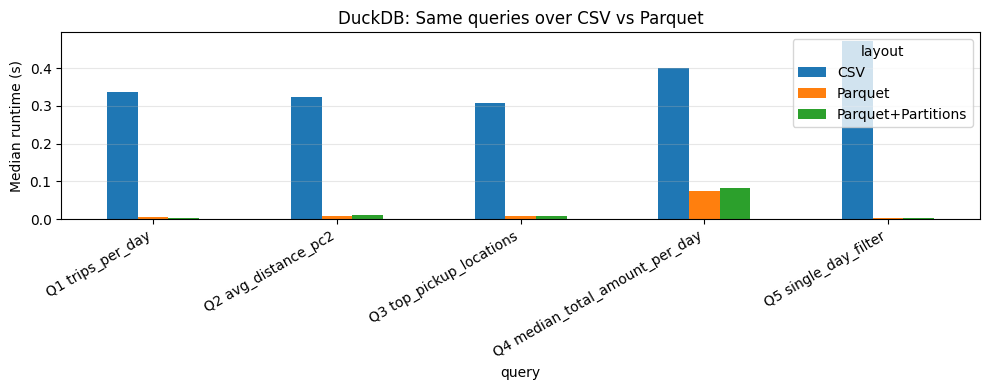

In [14]:
pivot = timings_df.pivot(index='query', columns='layout', values='median_s')
ax = pivot.plot(kind='bar', figsize=(10,4))
ax.set_ylabel('Median runtime (s)')
ax.set_title('DuckDB: Same queries over CSV vs Parquet')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### Tiny exercise 2 (5–10 minutes)
Add one more query that highlights **column pruning**.

Example idea:
- Compare:
  - `SELECT AVG(total_amount) ... WHERE pickup_date = ...`
  - `SELECT * ... WHERE pickup_date = ...`

Time both on **Parquet(single)** and write 2–3 sentences: why should `SELECT *` be slower?


In [15]:
# Tiny exercise 2
# Add one query that highlights column pruning, and time it.
#
# Hints:
# - Compare a query that touches ONE column vs `SELECT *`.
# - Use `time_query(sql, runs=5, warmup=1)`.
# - Use `pq_ref` (single Parquet file) to keep it simple.

target_day = f"{YEAR}-{MONTH:02d}-04"

# Touches one measure column (+ filter column).
q_col = f"""
SELECT AVG(total_amount) AS avg_total
FROM {pq_ref}
WHERE pickup_date = DATE '{target_day}'
"""

# Touches all columns for the same predicate.
# LIMIT keeps notebook memory/runtime reasonable while preserving the contrast.
q_star = f"""
SELECT *
FROM {pq_ref}
WHERE pickup_date = DATE '{target_day}'
LIMIT 100000
"""

t_col = time_query(q_col, runs=5, warmup=1)
t_star = time_query(q_star, runs=5, warmup=1)

col_pruning_df = pd.DataFrame([
    {"query": "AVG(total_amount)", **t_col},
    {"query": "SELECT * (LIMIT 100000)", **t_star},
])

print(f"Parquet column-pruning demo for {target_day}")
col_pruning_df

Parquet column-pruning demo for 2024-01-04


,query,median_s,min_s,max_s
0,AVG(total_amount),0.004568,0.004026,0.006358
1,SELECT * (LIMIT 100000),0.259615,0.239954,0.265045


## 7) `EXPLAIN` and `EXPLAIN ANALYZE`
The goal is not memorizing plan syntax — it’s being able to point at evidence of:
- file scan operator (CSV vs Parquet),
- filters applied early (predicate pushdown),
- projected columns (column pruning),
- partition discovery (hive partitions).


In [16]:
def explain(sql: str) -> str:
    # DuckDB returns one row with a text plan.
    return con.execute("EXPLAIN " + sql).fetchone()[1]

def explain_analyze(sql: str) -> str:
    return con.execute("EXPLAIN ANALYZE " + sql).fetchone()[1]

probe_sql = QUERY_TEMPLATES["Q5 single_day_filter"].format(ref=part_ref, year=YEAR, month=MONTH)
print("SQL:", probe_sql)
print("EXPLAIN (partitioned parquet):")
print(explain(probe_sql)[:2000])


SQL: 
    SELECT COUNT(*) AS trips
    FROM read_parquet('/content/BDLab/Lab2/out/trips_partitioned/**/*.parquet', hive_partitioning=1)
    WHERE pickup_date = DATE '2024-01-04'
  
EXPLAIN (partitioned parquet):
┌───────────────────────────┐
│    UNGROUPED_AGGREGATE    │
│    ────────────────────   │
│        Aggregates:        │
│        count_star()       │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│       READ_PARQUET        │
│    ────────────────────   │
│         Function:         │
│        READ_PARQUET       │
│                           │
│       File Filters:       │
│ (pickup_date = '2024-01-04│
│          '::DATE)         │
│                           │
│    Scanning Files: 1/7    │
│                           │
│        ~79700 Rows        │
└───────────────────────────┘



### Tiny exercise 3 (5–10 minutes)
Run `EXPLAIN` for the **same logical query** on CSV and Parquet.

Find and report (in plain text):
- the scan operator name,
- whether the filter is shown near the scan,
- whether only required columns are scanned.

*Hint:* compare `EXPLAIN` outputs for `csv_ref` vs `pq_ref`.


In [19]:
# Tiny exercise 3
# Run EXPLAIN for the SAME logical query on CSV and on Parquet.
#
# Hints:
# - Use the helper `explain(sql)` defined above.
# - Use `csv_ref` and `pq_ref`.
# - Look for:
#   * scan operator name (CSV vs Parquet)
#   * Filters near the scan (pushdown)
#   * Which columns are scanned (column pruning)

ex_q = f"""
SELECT AVG(total_amount) AS avg_total
FROM {{ref}}
WHERE pickup_date = DATE '{YEAR}-{MONTH:02d}-04'
"""

csv_sql = ex_q.format(ref=csv_ref)
pq_sql = ex_q.format(ref=pq_ref)

csv_plan = explain(csv_sql)
pq_plan = explain(pq_sql)

print("=== EXPLAIN: CSV ===")
print(csv_plan[:2500])
print()

=== EXPLAIN: CSV ===
┌───────────────────────────┐
│    UNGROUPED_AGGREGATE    │
│    ────────────────────   │
│    Aggregates: avg(#0)    │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│        total_amount       │
│                           │
│        ~222933 Rows       │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│             #1            │
│                           │
│        ~222933 Rows       │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│           FILTER          │
│    ────────────────────   │
│ (pickup_date = '2024-01-04│
│          '::DATE)         │
│                           │
│        ~222933 Rows       │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│       READ_CSV_AUTO       │
│    ────────────────────   │
│         Function:         │
│       READ_CSV_AUTO       │
│                  

In [20]:
print("=== EXPLAIN: Parquet ===")
print(pq_plan[:2500])
print()

=== EXPLAIN: Parquet ===
┌───────────────────────────┐
│    UNGROUPED_AGGREGATE    │
│    ────────────────────   │
│    Aggregates: avg(#0)    │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│        total_amount       │
│                           │
│        ~120246 Rows       │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│       READ_PARQUET        │
│    ────────────────────   │
│         Function:         │
│        READ_PARQUET       │
│                           │
│        Projections:       │
│        total_amount       │
│                           │
│          Filters:         │
│ pickup_date='2024-01-04': │
│           :DATE           │
│                           │
│        ~120246 Rows       │
└───────────────────────────┘




In [23]:
findings = [
    "CSV plan should show a CSV scan (text parsing path), while Parquet plan should show a Parquet scan.",
    "The filter on pickup_date should appear close to the scan stage (predicate pushdown behavior).",
    "Parquet should read only required columns (pickup_date + total_amount), demonstrating column pruning.",
]

print("Findings:")
for i, f in enumerate(findings, start=1):
    print(f"{i}. {f}")

Findings:
1. CSV plan should show a CSV scan (text parsing path), while Parquet plan should show a Parquet scan.
2. The filter on pickup_date should appear close to the scan stage (predicate pushdown behavior).
3. Parquet should read only required columns (pickup_date + total_amount), demonstrating column pruning.


# Mini-assignment (end of lab)
Designed for manual grading + oral explanation.

## Assignment A — Partition pruning demo
1. Using the **partitioned** dataset, run two queries:
   - `pickup_date = '...-04'`
   - `pickup_date BETWEEN '...-03' AND '...-05'`
2. Time both and explain why the partitioned layout helps.

## Assignment B — Practical recommendation
You’re advising a team that currently stores daily logs as CSV.
- Propose a migration plan to Parquet.
- Mention at least 2 risks/tradeoffs (schema changes, small files, partition strategy, compatibility).

## Assignment C — Oral prompts (prepare short answers)
- Why is Parquet usually faster than CSV for analytics?
- What is **column pruning** and why does it matter?
- What is **predicate pushdown**?
- What is **partition pruning**?
- When can partitioning make things worse?


In [18]:
# Mini-assignment solution cell: Assignment A (Partition pruning demo)
# Uses the partitioned Parquet reference created earlier: part_ref

one_day = f"{YEAR}-{MONTH:02d}-04"
range_start = f"{YEAR}-{MONTH:02d}-03"
range_end = f"{YEAR}-{MONTH:02d}-05"

sql_one_day = f"""
SELECT COUNT(*) AS trips
FROM {part_ref}
WHERE pickup_date = DATE '{one_day}'
"""

sql_range = f"""
SELECT COUNT(*) AS trips
FROM {part_ref}
WHERE pickup_date BETWEEN DATE '{range_start}' AND DATE '{range_end}'
"""

t_one_day = time_query(sql_one_day, runs=5, warmup=1)
t_range = time_query(sql_range, runs=5, warmup=1)

one_day_count = con.execute(sql_one_day).fetchone()[0]
range_count = con.execute(sql_range).fetchone()[0]

assignment_a_df = pd.DataFrame([
    {"query": f"pickup_date = {one_day}", "trips": one_day_count, **t_one_day},
    {"query": f"pickup_date BETWEEN {range_start} AND {range_end}", "trips": range_count, **t_range},
])

assignment_a_df["speedup_vs_range"] = assignment_a_df["median_s"].max() / assignment_a_df["median_s"]

print("Assignment A results (partitioned Parquet):")
assignment_a_df

Assignment A results (partitioned Parquet):


,query,trips,median_s,min_s,max_s,speedup_vs_range
0,pickup_date = 2024-01-04,101604,0.002243,0.001925,0.006694,1.096406
1,pickup_date BETWEEN 2024-01-03 AND 2024-01-05,284740,0.002459,0.002397,0.002675,1.000000


### Assignment B — Practical recommendation (sample answer)

**Migration plan from CSV to Parquet**
1. Keep CSV as source of truth temporarily, and build a parallel Parquet pipeline for a trial period.
2. Standardize schema (types, null handling, timestamp timezone rules) before writing Parquet.
3. Write Parquet with a sensible partition key (for this workload, `pickup_date`), and avoid excessive tiny files.
4. Validate parity with automated checks: row counts, aggregates, min/max dates, and sampled row-level comparisons.
5. Switch read workloads to Parquet once parity and performance targets are met, then retire CSV outputs gradually.

**Risks / tradeoffs**
- Schema drift and type inconsistencies can break readers or produce silent casting issues.
- Too many small partition files can hurt performance due to file-open overhead and metadata costs.
- Bad partition strategy (too high/low cardinality) can reduce pruning benefits or create skew.
- Compatibility constraints may require fallback exports for tools that still expect CSV.

**Recommendation**
For analytical workloads, use Parquet as the primary storage format and keep CSV only for interoperability or ad-hoc exchange.

### Assignment C — Oral prompts (short answers)

**Why is Parquet usually faster than CSV for analytics?**
Parquet is columnar, typed, and compressed, so engines avoid text parsing overhead and read less data from disk. CSV requires parsing full text rows and often scans unnecessary columns.

**What is column pruning and why does it matter?**
Column pruning means reading only columns required by the query. It matters because I/O is usually the bottleneck in analytics, so fewer bytes read means lower latency and cost.

**What is predicate pushdown?**
Predicate pushdown applies filters as early as possible in the scan layer, reducing data passed to later operators.

**What is partition pruning?**
Partition pruning skips entire folders/files based on partition keys (for example `pickup_date=...`), so irrelevant partitions are never scanned.

**When can partitioning make things worse?**
Partitioning can hurt when it creates many tiny files, uses poor keys, or when queries rarely filter by the partition column. In those cases, metadata and file-management overhead can outweigh pruning benefits.

## What you should have at the end
- `out/trips.csv`
- `out/trips.parquet`
- `out/trips_partitioned/` with `pickup_date=YYYY-MM-DD/` folders
- A timing table + bar chart comparing CSV vs Parquet
- Ability to explain the observed differences using `EXPLAIN`


## References (optional)

- DuckDB docs: https://duckdb.org/docs/
- DuckDB Parquet: https://duckdb.org/docs/data/parquet/overview.html
- DuckDB aggregates (`quantile_cont`): https://duckdb.org/docs/sql/functions/aggregates.html
- PyArrow `write_dataset`: https://arrow.apache.org/docs/python/generated/pyarrow.dataset.write_dataset.html
